In [1]:
import os
import sys
import json
import matplotlib

import pandas as pd
import numpy as np
import anndata as ad
import scanpy as sc
import seaborn as sns
import sklearn.metrics
import tacco as tc
import time 
import tracemalloc 



In [ ]:
import os
import scanpy as sc
import anndata as ad


# -------------------------------------------------------------------
# Set this to the directory containing your input .h5ad files.
# -------------------------------------------------------------------

DATA_DIR = os.environ.get("XENIUM_DATA_DIR", "path/to/data")


# -------------------------------------------------------------------
# Load samples
# -------------------------------------------------------------------

sample_files = {
    "NC1": "sample_NC1.h5ad",
    "C2": "sample_C2.h5ad",
    "C4": "sample_C4.h5ad",
    "C3": "sample_C3.h5ad",
    "NC2": "sample_NC2.h5ad",
    "NC3": "sample_NC3.h5ad",
    "C1": "sample_C1.h5ad",
    "NC4": "sample_NC4.h5ad",
    "S_C5": "sample_S_C5.h5ad",
    "S_NC13": "sample_S_NC13.h5ad",
    "S_C6": "sample_S_C6.h5ad",
    "S_C7": "sample_S_C7.h5ad",
    "NC8": "sample_NC8.h5ad",
    "NC5": "sample_NC5.h5ad",
    "S_C10": "sample_S_C10.h5ad",
    "S_C9": "sample_S_C9.h5ad",
    "S_C8": "sample_S_C8.h5ad",
}


# Load all AnnData objects
adatas = {
    sample: sc.read(os.path.join(DATA_DIR, filename))
    for sample, filename in sample_files.items()
}


# -------------------------------------------------------------------
# Concatenate samples
# -------------------------------------------------------------------

combined = ad.concat(
    list(adatas.values()),
    axis=0,
    join="outer",
    label="sample",
    keys=list(adatas.keys()),
)


# -------------------------------------------------------------------
# Assign experimental conditions
# -------------------------------------------------------------------

condition_map = {
    "NC1": "Non-Cytopenic",
    "NC2": "Non-Cytopenic",
    "NC3": "Non-Cytopenic",
    "NC4": "Non-Cytopenic",
    "NC5": "Non-Cytopenic",
    "NC8": "Non-Cytopenic",
    "S_NC13": "Non-Cytopenic",

    "C1": "Cytopenic",
    "C2": "Cytopenic",
    "C3": "Cytopenic",
    "C4": "Cytopenic",
    "S_C5": "Cytopenic",
    "S_C6": "Cytopenic",
    "S_C7": "Cytopenic",
    "S_C8": "Cytopenic",
    "S_C9": "Cytopenic",
    "S_C10": "Cytopenic",
}


combined.obs["condition"] = combined.obs["sample"].map(condition_map)


# -------------------------------------------------------------------
# Standardize cell-type annotation
# -------------------------------------------------------------------

combined.obs["Tacco_pred_cell_type"] = (
    combined.obs["Tacco_pred_cell_type"]
    .replace("Myeloma.mesenchymal", "Mesenchymal")
)


/usr/local/Caskroom/mambaforge/base/envs/TACCO_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/var/folders/8y/pr3hwpm17132d6nyjkjsrys00000gq/T/ipykernel_86072/3984161367.py:54: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  combined.obs['Tacco_pred_cell_type'] = combined.obs['Tacco_pred_cell_type'].replace('Myeloma.mesenchymal', 'Mesenchymal')


Cell Type Color Mapping:
 1. B.cell               -> RGB(np.float64(0.122), np.float64(0.467), np.float64(0.706))
 2. B.prog               -> RGB(np.float64(0.682), np.float64(0.78), np.float64(0.91))
 3. Defensin+.neutrophil -> RGB(np.float64(1.0), np.float64(0.498), np.float64(0.055))
 4. Endothelial          -> RGB(np.float64(1.0), np.float64(0.733), np.float64(0.471))
 5. Erythrocyte          -> RGB(np.float64(0.173), np.float64(0.627), np.float64(0.173))
 6. FCGR3B+.neutrophil   -> RGB(np.float64(0.596), np.float64(0.875), np.float64(0.541))
 7. GMP                  -> RGB(np.float64(0.839), np.float64(0.153), np.float64(0.157))
 8. HSC                  -> RGB(np.float64(1.0), np.float64(0.596), np.float64(0.588))
 9. Infl.mesenchymal     -> RGB(np.float64(0.58), np.float64(0.404), np.float64(0.741))
10. LTF+.Neutrophil      -> RGB(np.float64(0.773), np.float64(0.69), np.float64(0.835))
11. MDP                  -> RGB(np.float64(0.549), np.float64(0.337), np.float64(0.294))
12. ME

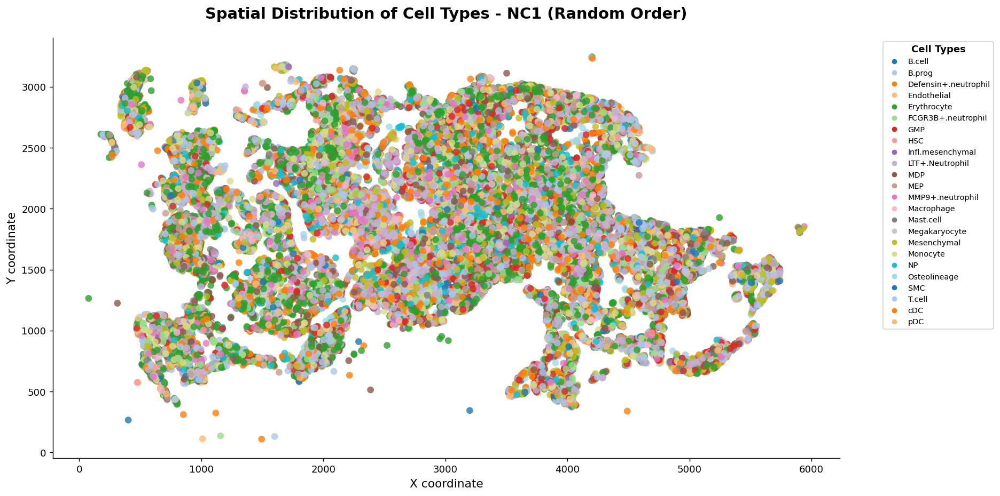

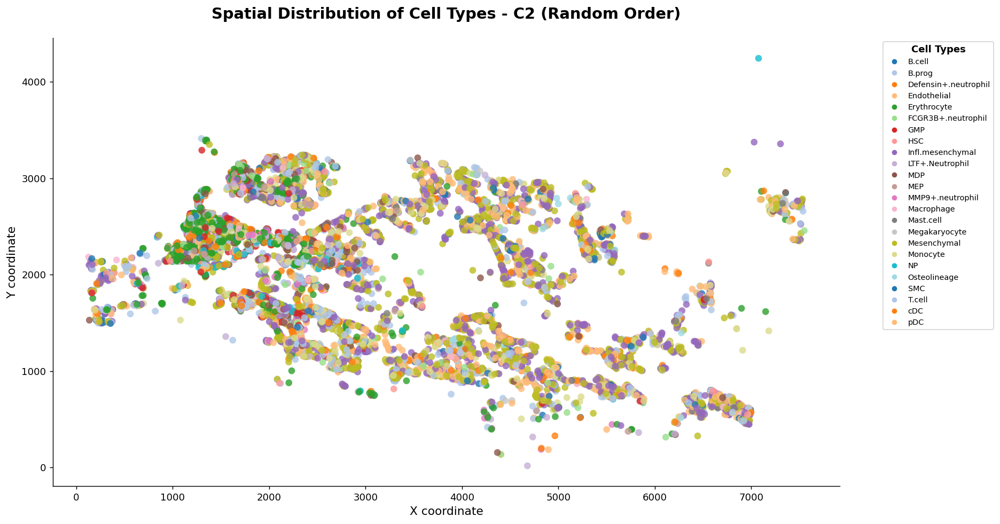

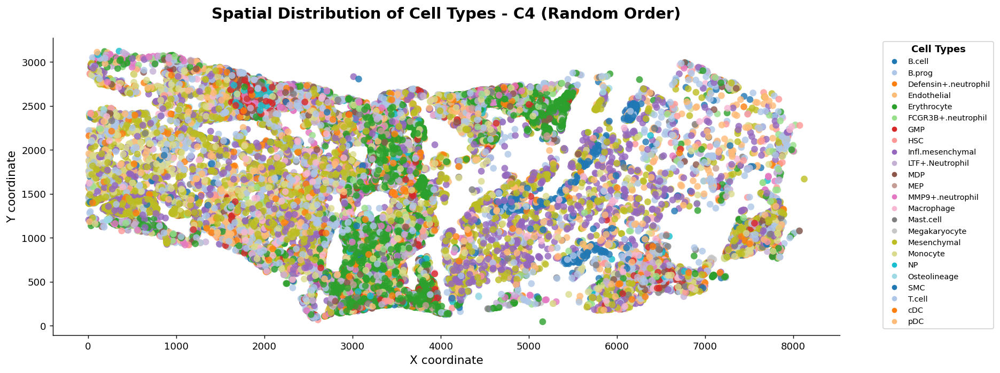

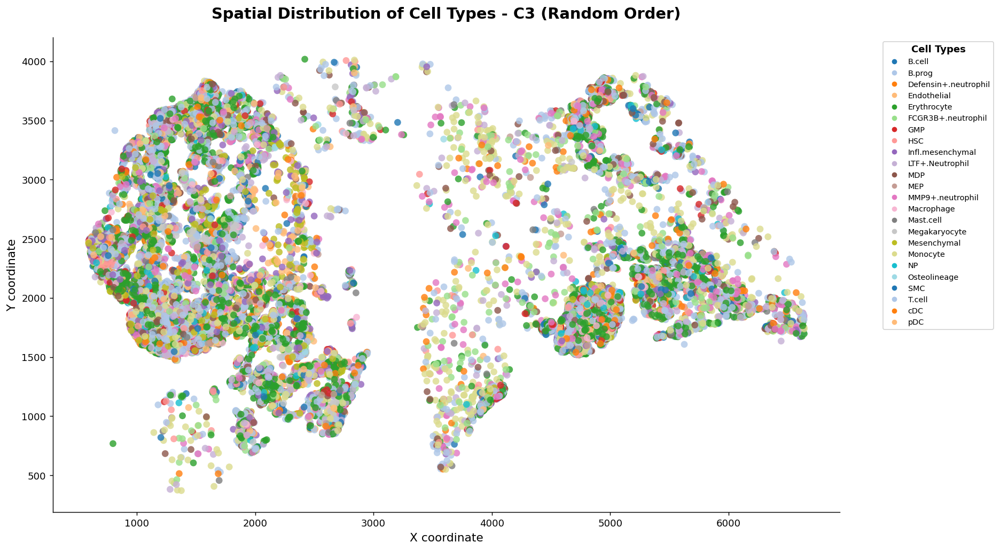

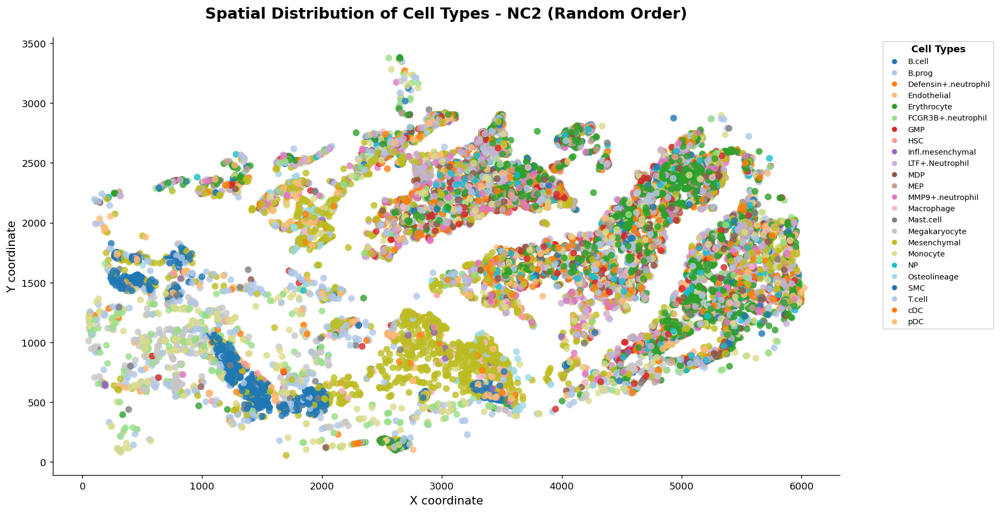

...

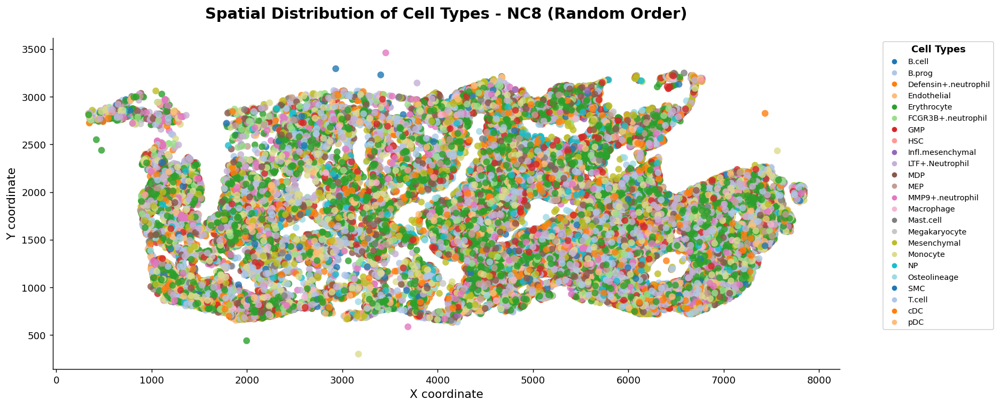

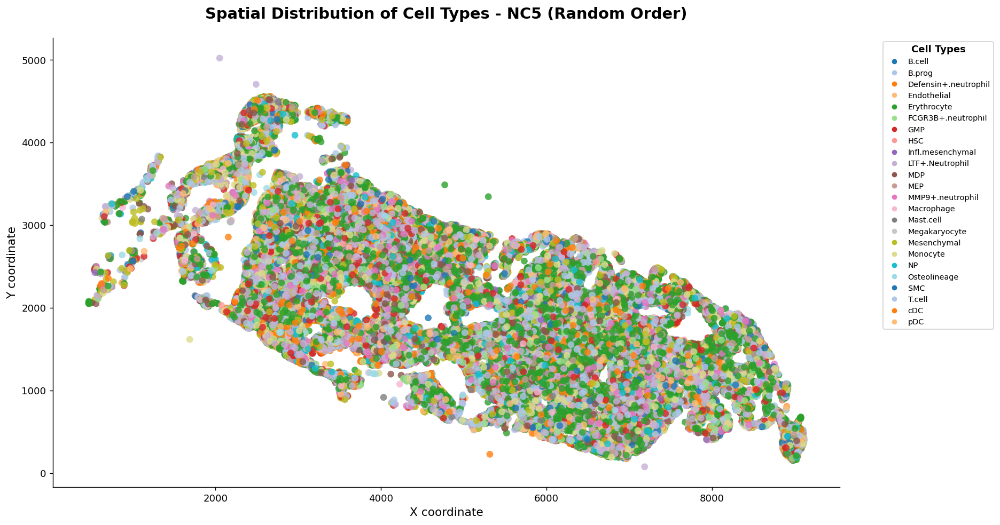

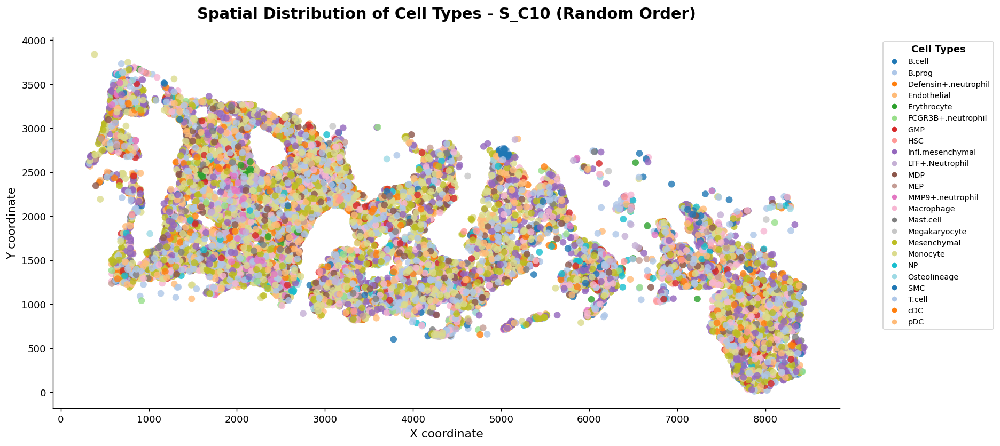

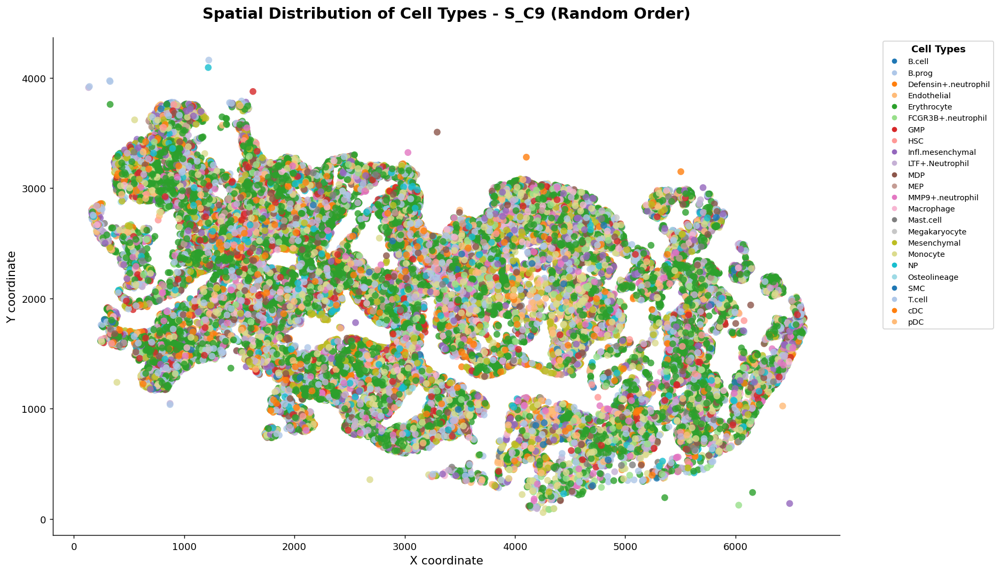

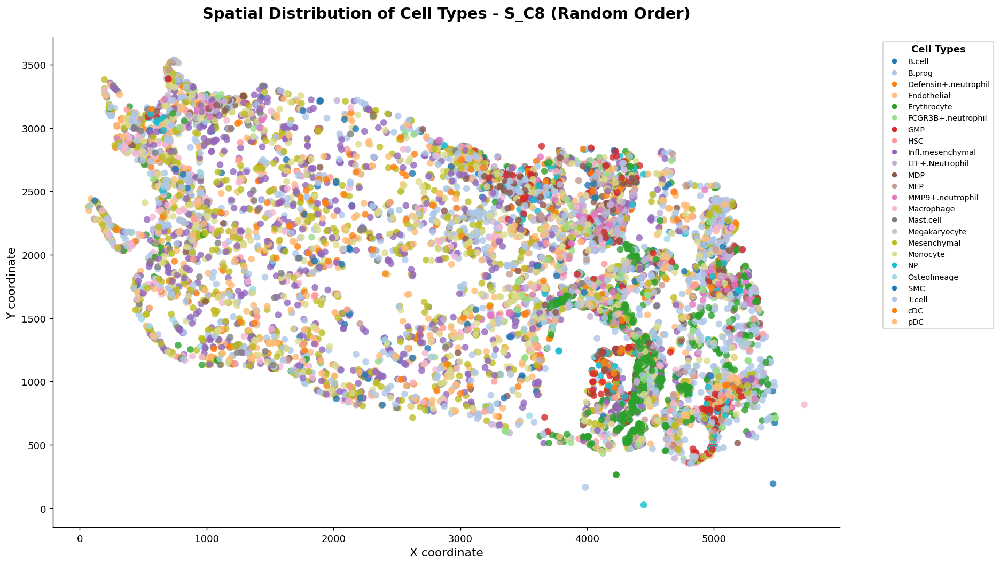

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
import numpy as np

# Set DPI for moderate resolution output
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.dpi'] = 300

# Get all samples
samples = combined.obs['sample'].unique()

# Create a consistent color palette for all cell types across samples
# IMPORTANT: Sort cell types to ensure consistent color assignment
all_cell_types = sorted(combined.obs['Tacco_pred_cell_type'].unique())
colors = sns.color_palette("tab20", n_colors=len(all_cell_types))
cell_type_colors = dict(zip(all_cell_types, colors))

# Print color mapping for verification
print("Cell Type Color Mapping:")
print("=" * 50)
for i, (cell_type, color) in enumerate(cell_type_colors.items()):
    print(f"{i+1:2d}. {cell_type:<20} -> RGB{tuple(np.round(color, 3))}")
print("=" * 50)

# Create spatial plots for each sample
for sample in samples:
        
    # Filter data for current sample
    sample_mask = combined.obs['sample'] == sample
    sample_data = combined[sample_mask, :]
    
    # Get spatial coordinates and cell types
    x_coords = sample_data.obsm['spatial'][:, 0]
    y_coords = sample_data.obsm['spatial'][:, 1]
    cell_types = sample_data.obs['Tacco_pred_cell_type']
    
    # Create figure with larger size for better visibility
    fig, ax = plt.subplots(figsize=(14.5, 11.6))
    
    # Create arrays for all coordinates and colors
    all_x = []
    all_y = []
    all_colors = []
    all_labels = []
    
    # Collect all points with their colors
    for cell_type in sorted(cell_types.unique()):
        mask = cell_types == cell_type
        if mask.sum() > 0:  # Only add if there are cells of this type
            cell_x = x_coords[mask]
            cell_y = y_coords[mask]
            cell_color = [cell_type_colors[cell_type]] * len(cell_x)
            cell_label = [cell_type] * len(cell_x)
            
            all_x.extend(cell_x)
            all_y.extend(cell_y)
            all_colors.extend(cell_color)
            all_labels.extend(cell_label)
    
    # Convert to numpy arrays
    all_x = np.array(all_x)
    all_y = np.array(all_y)
    all_colors = np.array(all_colors)
    all_labels = np.array(all_labels)
    
    # Randomly shuffle the order of all points
    random_indices = np.random.permutation(len(all_x))
    all_x = all_x[random_indices]
    all_y = all_y[random_indices]
    all_colors = all_colors[random_indices]
    all_labels = all_labels[random_indices]
    
    # Plot all points in random order
    ax.scatter(all_x, all_y, 
              c=all_colors, 
              s=50,  # Big dots
              alpha=0.8, 
              edgecolors='none')
    
    # Create legend with unique cell types (maintaining consistent order)
    legend_elements = []
    for cell_type in sorted(cell_types.unique()):
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                        markerfacecolor=cell_type_colors[cell_type], 
                                        markersize=8, label=cell_type))
    
    # Customize the plot
    ax.set_title(f'Spatial Distribution of Cell Types - {sample} (Random Order)', 
                fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('X coordinate', fontsize=12)
    ax.set_ylabel('Y coordinate', fontsize=12)
    
    # Add legend with smaller font to fit all cell types
    legend = ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', 
                      fontsize=8, markerscale=0.8)
    legend.set_title('Cell Types', prop={'size': 10, 'weight': 'bold'})
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Ensure equal aspect ratio to maintain spatial relationships
    ax.set_aspect('equal')
    
    # Tight layout to prevent legend cutoff
    plt.tight_layout()
    
    # Save as moderate-resolution PNG
    output_filename = f'spatial_map_{sample}_Tacco_pred_cell_type_random.png'
    plt.savefig(output_filename, 
                dpi=150, 
                bbox_inches='tight', 
                facecolor='white',
                edgecolor='none')
    
    plt.show()
    
